# Center blob input with JAX (open vs toroidal)

This notebook mirrors `wta2d_center_blob_demo.ipynb` but uses a JAX-accelerated
backend (`wta2d.jax_backend`) with local Gaussian kernels and 2D convolution.

We use a fixed center blob that disappears halfway through the simulation and
compare **open** vs **toroidal** boundary conditions, saving GIFs under the
`Examples` folder.

In [1]:
# If needed, install JAX (on CPU by default). Uncomment if your environment lacks JAX.
# !pip install --upgrade "jax[cpu]"

import pathlib, sys

root = pathlib.Path.cwd()
if (root / "wta2d").exists() and str(root) not in sys.path:
    sys.path.insert(0, str(root))

import numpy as np
import matplotlib.pyplot as plt

import wta2d
from wta2d import viz, save_gif
from wta2d.inputs import pattern_input
import wta2d.jax_backend as wta2d_jax

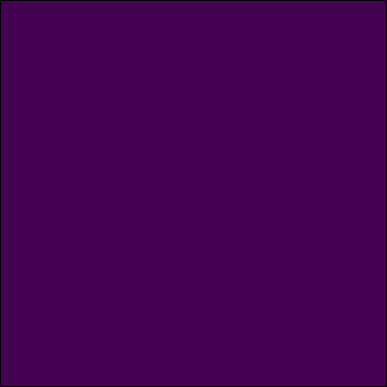

In [3]:
# Build a fixed center blob: 1 in a small disk at center, 0 elsewhere. Turns off at 50% of time.
side = 50
tlen = 8000
blob_radius = 3  # grid units from center (1-based)
scale = 1.0
turn_off_frac = 0.5

N, pos, _ = wta2d.make_grid(side)
center = (side + 1) / 2.0
dist_from_center = np.sqrt((pos[:, 0] - center) ** 2 + (pos[:, 1] - center) ** 2)
blob = np.zeros(N)
blob[dist_from_center <= blob_radius] = scale

#Inp = pattern_input(tlen, blob, scale=1.0, turn_off_after_frac=turn_off_frac)
Inp = 0.25*pattern_input(tlen, blob, scale=1.0, turn_off_after_frac=turn_off_frac) + wta2d.random_sparse_input(tlen, N, sparsity=0.55, scale=1.0)
#Inp = wta2d.random_sparse_input(tlen, N, sparsity=0.55, scale=1.0)


# Shared kernel / dynamics parameters (tweak here)

Ae = 0.7    # excitatory kernel height
ke = 1.4    # excitatory kernel width
Ai = 0.05 # inhibitory kernel height
ki = 3.75    # inhibitory kernel width

recov = 0.7
rstrength = 0.95

#Ae = 0.7
#ke = 1.0
#Ai = 0.0085
#ki = 7.0
#h = 0.001
B = 10.0
C = 10.0
ra = 0.01
recov = 0.25
rstrength = 0.60
zinh = 10.0
save_every = 10  # store every 10 steps to reduce memory
radius = None    # or set an explicit kernel radius (e.g. 4)


# Run JAX-accelerated simulations with open vs toroidal boundaries
xs_open_jax = wta2d_jax.simulate_conv_jax(
    Inp,
    side=side,
    Ae=Ae, ke=ke, Ai=Ai, ki=ki,
    B=B, C=C, ra=ra, recov=recov,
    rstrength=rstrength, zinh=zinh,
    boundary="open",
    save_every=save_every,
    radius=radius,
)

# xs_toroidal_jax = wta2d_jax.simulate_conv_jax(
#     Inp,
#     side=side,
#     Ae=Ae, ke=ke, Ai=Ai, ki=ki,
#     h=h, B=B, C=C, ra=ra, recov=recov,
#     rstrength=rstrength, zinh=zinh,
#     boundary="toroidal",
#     save_every=save_every,
#     radius=radius,
# )


# Save GIFs to Examples folder and display them
from IPython.display import Image, display

xs_open = np.asarray(xs_open_jax)
#xs_toroidal = np.asarray(xs_toroidal_jax)

save_gif(xs_open, side, "center_blob_open_jax3.gif", cmap="viridis", border=1, nframe=80)
#save_gif(xs_toroidal, side, "center_blob_toroidal_jax.gif", cmap="viridis", border=1, nframe=40)

#print("Saved Examples/center_blob_open_jax.gif and Examples/center_blob_toroidal_jax.gif\"))
display(Image(filename="Examples/center_blob_open_jax3.gif"))
#display(Image(filename="Examples/center_blob_toroidal_jax.gif"))